# Gruppieren und Aggregate

## Beispieldatei
Wir nutzen im Beispiel die `legislators-current.csv`, die die aktuellen Mitglieder des Kongresses abbildet.

Wir wollen Datensätze anhand von Spaltennamen gruppieren und mitilfe von Aggregatsfunktionen Werte zusammenfassen. `groupby()` ähnelt stark der SQL-Entsprechung `GROUP BY`. 

Zum Beispiel könnten wir im Datensatz nach `state` gruppieren und die Anzahl der Senatoren aufsummieren. Für dieses Aggregat stellt Pandas viele Funktionen zur Verfügung.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/legislators-current.csv", usecols=["first_name", "last_name", "gender", "type", "state", "birthday"])
df

,last_name,first_name,birthday,gender,type,state
0,Brown,Sherrod,1952-11-09,M,sen,OH
1,Cantwell,Maria,1958-10-13,F,sen,WA
2,Cardin,Benjamin,1943-10-05,M,sen,MD
3,Carper,Thomas,1947-01-23,M,sen,DE
4,Casey,Robert,1960-04-13,M,sen,PA
...,...,...,...,...,...,...
531,Stansbury,Melanie,1979-01-31,F,rep,NM
532,Ellzey,Jake,1970-01-24,M,rep,TX
533,Brown,Shontel,1975-06-24,F,rep,OH
534,Carey,Mike,1971-03-13,M,rep,OH


## Das DataFrameGroupBy Objekt
Der `groupby`-Funktion können wir einen Spaltennamen übergeben, oder eine Liste mit Spaltennamen oder einen Numpy-Array mit Zeilen-Indizies.

Wenn wir die `groupby` Funktion für eine Spalte ausführen, erhalten wir ein sogenanntes `DataFrameGroupBy`-Objekt. Für jedes Bestandteil des übergebenen Spalteneintrags erhalten wir einen Eintrag.

In [2]:
# Gruppiert nach State
grouped = df.groupby("state")

In [3]:
# Das Gruppenobjekt in eine liste umformen
# Liste an Index 0 anzeigen
list(grouped)[0]

('AK',
      last_name first_name    birthday gender type state
 142  Murkowski       Lisa  1957-05-22      F  sen    AK
 308   Sullivan        Dan  1964-11-13      M  sen    AK)

## groupby
Um dieses Objekt zu nutzen, müssen wir Aggregatsfunktionen darauf anwenden.
Hier im Beipiel gruppieren wir nach State und führen auf der Spalte `state` die Aggregatsfunktion `size()` aus. Wir zählen also die Anzahl der Kongressmitglieder gruppiert nach State.

In [4]:
# Anzahl Kongressmitglieder nach State
result = df.groupby(["state", "gender"]).size()
result[:10], type(result)

(state  gender
 AK     F          1
        M          1
 AL     F          1
        M          8
 AR     M          6
 AS     F          1
 AZ     F          3
        M          8
 CA     F         20
        M         34
 dtype: int64,
 pandas.core.series.Series)

## Groupby eine Liste von Spalten übergeben
Ebenso, wie wir das auch in SQL machen können, können wir nach mehreren Spalten gruppieren. Hier gruppieren wir nach `state` und dann nach `gender`. Wir erhalten eine Multi-Index-Series. `Multi-index-Serien` werden in diesem Tutorial nicht besprochen, da das zu weit führen würde. Man kann aber verhindern, dass eine Multiindex-Serie angelegt wird, indem man `as_index=False` angibt.

In [5]:
# Gruppiere nach state und gender und zähle die Vorkommen
result = df.groupby(["state", "gender"]).size()
result

state  gender
AK     F         1
       M         1
AL     F         1
       M         8
AR     M         6
                ..
WI     M         8
WV     F         2
       M         3
WY     F         2
       M         1
Length: 96, dtype: int64

# Weitere Aggregatsmethoden

Gegeben ist ein Dictionary, welches zwei Baseball-Teams repräsentiert. Die Spalten Team, Position und Alter sollen zu einem
DataFrame konvertiert werden.

- Welches Durchschnittsalter hat jedes Team?
- Berechne mit, max, avg, std und var je Team und Position
- Welches Durchschnittsalter haben die Pitcher der Red Sox?

In [6]:
data = {"Team": ["Red Sox", "Red Sox", "Red Sox", "Red Sox", "Red Sox", "Red Sox", "Yankees", "Yankees", "Yankees", "Yankees", "Yankees", "Yankees"],
        "Pos": ["Pitcher", "Pitcher", "Pitcher", "Not Pitcher", "Not Pitcher", "Not Pitcher", "Pitcher", "Pitcher", "Pitcher", "Not Pitcher", "Not Pitcher", "Not Pitcher"],
        "Age": [24, 28, 40, 22, 29, 33, 31, 26, 21, 36, 25, 31]}
df = pd.DataFrame(data)
df.head()

,Team,Pos,Age
0,Red Sox,Pitcher,24
1,Red Sox,Pitcher,28
2,Red Sox,Pitcher,40
3,Red Sox,Not Pitcher,22
4,Red Sox,Not Pitcher,29


In [7]:
# durchschnittsalter der Teams       DE "Age": PROMEDIO, max, min, std, var, median, std
mean_team_age = df.groupby("Team").agg({"Age": ["mean", "max", "min", "std", "var", "median", "size"]})
mean_team_age

Age                                         
              mean max min       std        var median size
Team                                                       
Red Sox  29.333333  40  22  6.501282  42.266667   28.5    6
Yankees  28.333333  36  21  5.354126  28.666667   28.5    6

In [8]:
# gruppiert nach zwei Spalten, resultiert in Multi Index.
#grouped_multiple = df.groupby(["Team", "Pos"], as_index=False).agg({"Age":["mean", "max", "min", "std", "var", "median", "size"]})
#grouped_multiple

grouped_multiple = df.groupby(["Team", "Pos"]).agg({"Age":["mean", "max", "min", "std", "var", "median", "size"]})
grouped_multiple.index

MultiIndex([('Red Sox', 'Not Pitcher'),
            ('Red Sox',     'Pitcher'),
            ('Yankees', 'Not Pitcher'),
            ('Yankees',     'Pitcher')],
           names=['Team', 'Pos'])

In [9]:
df

,Team,Pos,Age
0,Red Sox,Pitcher,24
1,Red Sox,Pitcher,28
2,Red Sox,Pitcher,40
3,Red Sox,Not Pitcher,22
4,Red Sox,Not Pitcher,29
5,Red Sox,Not Pitcher,33
6,Yankees,Pitcher,31
7,Yankees,Pitcher,26
8,Yankees,Pitcher,21
9,Yankees,Not Pitcher,36


# Übung: Daten gruppieren und aggregieren

## Szenario
Ein Fitnessstudio analysiert seine Mitglieder, um herauszufinden, wie sich **Alter, Gewicht und Größe** je nach Mitgliedsstatus (Aktiv oder Inaktiv) unterscheiden.  
Deine Aufgabe ist es, den Datensatz zu **gruppieren und verschiedene Aggregationen** durchzuführen.

---
- Gruppiere den df-DataFrame nach der Spalte "status".
- Berechne folgende Kennzahlen für jedes Mitgliedsstatus ("Active" und "Inactive") mit .agg():
- - Durchschnittliches Alter (age) → "mean"
- - Maximales Gewicht (weight_kg) → "max"
- - Minimale Größe (height_cm) → "min"
- - Summe Mitglieder
 
- Speichere das Ergebnis als df_summary.
- Sortiere den df_summary-DataFrame nach "age" in absteigender Reihenfolge (sort())

## Zusatzaufgabe

- Runde alle Werte auf eine Nachkommastelle.
- Erstelle einen Bar-Plot, der den Status und das Durchschnittsalter darstellt

,member_id,status,age,weight_kg,height_cm
0,101,Active,25,70,175
1,102,Inactive,40,85,180
2,103,Active,30,78,169
3,104,Active,35,90,182
4,105,Inactive,50,95,178
5,106,Active,28,72,172
6,107,Inactive,45,88,185
7,108,Active,33,80,176


[('Active',
     member_id  status  age  weight_kg  height_cm
  0        101  Active   25         70        175
  2        103  Active   30         78        169
  3        104  Active   35         90        182
  5        106  Active   28         72        172
  7        108  Active   33         80        176),
 ('Inactive',
     member_id    status  age  weight_kg  height_cm
  1        102  Inactive   40         85        180
  4        105  Inactive   50         95        178
  6        107  Inactive   45         88        185)]

<Axes: xlabel='status'>

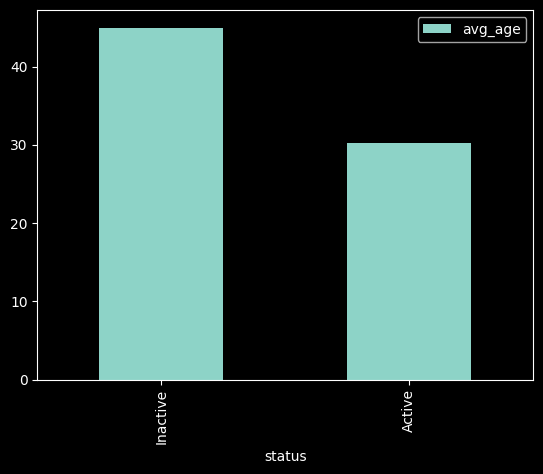

In [33]:
#  Mitgliederdaten
df = pd.DataFrame({
    "member_id": [101, 102, 103, 104, 105, 106, 107, 108],
    "status": ["Active", "Inactive", "Active", "Active", "Inactive", "Active", "Inactive", "Active"],
    "age": [25, 40, 30, 35, 50, 28, 45, 33],
    "weight_kg": [70, 85, 78, 90, 95, 72, 88, 80],
    "height_cm": [175, 180, 169, 182, 178, 172, 185, 176]
})
display(df)

# agrupar a partir de "status"
status_groupings = df.groupby("status")

display(list(status_groupings))

# calcular Kennzahlen para cada status con .agg()
df_summary = df.groupby("status").agg(
    avg_age=("age", "mean"),
    max_weight=("weight_kg", "max"),
    min_height=("height_cm", "min"),
    members=("age", "size")
)

# save result as "df_summary" & sortiere nach "age" absteigendere Reihenfolge
df_summary = df_summary.sort_values(by="avg_age", ascending=False)


# Runde alle Werte auf eine (1) Nachkommastelle
df_summary = df_summary.round(1)

# lo mismo pero simplificado / profesional --->
"""df_summary = (
    df.groupby("status")
      .agg(
          avg_age=("age", "mean"),
          max_weight=("weight_kg", "max"),
          min_height=("height_cm", "min"),
          members=("age", "size")
      )
      .sort_values(by="avg_age", ascending=False)
      .round(1)
)"""
# ----------------------------------------------

# bar-plot
df_summary.plot(kind="bar", y="avg_age")


In [11]:
# Bar Plot